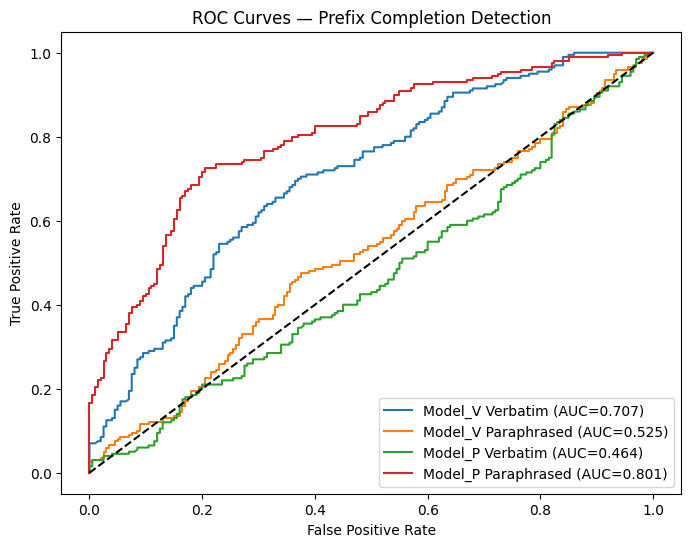

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score


############################################
# FUNCTION TO LOAD + COMPUTE ROC
############################################

def get_roc(contaminated_file, clean_file):
    
    contaminated = pd.read_csv(contaminated_file)
    clean = pd.read_csv(clean_file)

    contaminated["label"] = 1
    clean["label"] = 0

    df = pd.concat([contaminated, clean], ignore_index=True)

    scores = df["score"]
    labels = df["label"]

    fpr, tpr, _ = roc_curve(labels, scores)
    auc = roc_auc_score(labels, scores)

    return fpr, tpr, auc


############################################
# FILE PATHS
############################################

mv_verbatim = "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_v_verbatim.csv"
mv_clean = "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_v_clean.csv"

mv_para = "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_v_paraphrase.csv"

mp_verbatim = "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_p_verbatim.csv"
mp_clean = "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_p_clean.csv"

mp_para = "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_p_paraphrase.csv"


############################################
# COMPUTE ALL ROC CURVES
############################################

fpr1, tpr1, auc1 = get_roc(mv_verbatim, mv_clean)
fpr2, tpr2, auc2 = get_roc(mv_para, mv_clean)

fpr3, tpr3, auc3 = get_roc(mp_verbatim, mp_clean)
fpr4, tpr4, auc4 = get_roc(mp_para, mp_clean)


############################################
# PLOT ALL TOGETHER
############################################

plt.figure(figsize=(8,6))

plt.plot(fpr1, tpr1, label=f"Model_V Verbatim (AUC={auc1:.3f})")
plt.plot(fpr2, tpr2, label=f"Model_V Paraphrased (AUC={auc2:.3f})")

plt.plot(fpr3, tpr3, label=f"Model_P Verbatim (AUC={auc3:.3f})")
plt.plot(fpr4, tpr4, label=f"Model_P Paraphrased (AUC={auc4:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves — Prefix Completion Detection")

plt.legend()

plt.show()

In [4]:
import pandas as pd

v = pd.read_csv("/Users/amarsinha/Research_swifties/scores/prefix_scores_model_p_verbatim.csv")
c = pd.read_csv("/Users/amarsinha/Research_swifties/scores/prefix_scores_model_p_clean.csv")

print("Model_P Verbatim mean:", v["score"].mean())
print("Model_P Clean mean:", c["score"].mean())

Model_P Verbatim mean: 0.2582269756570087
Model_P Clean mean: 0.26319059269351464
